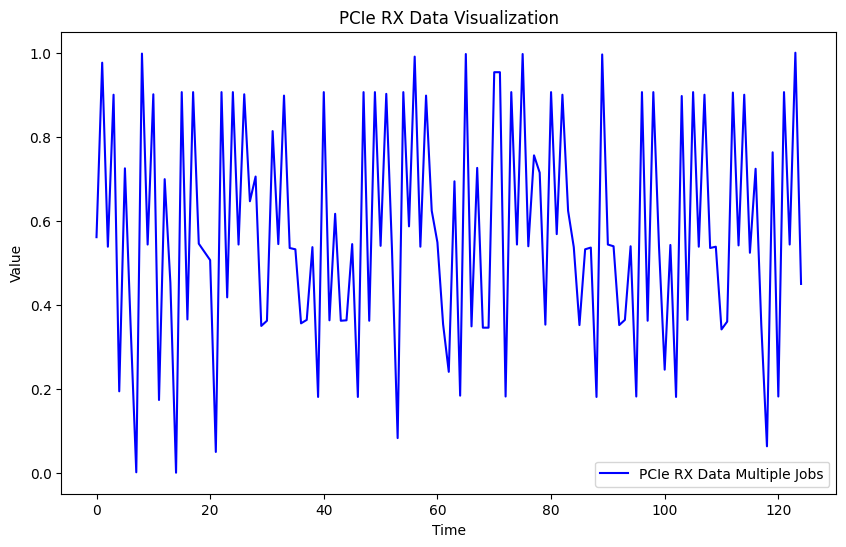

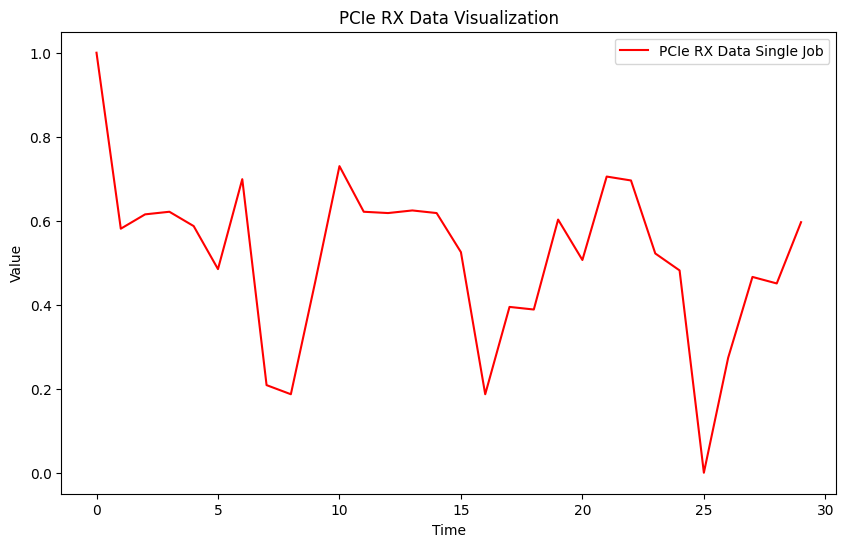

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMinMax
from tslearn.utils import to_time_series_dataset


df = pd.read_csv("./data/PCIe RX-data-2026-08-14 20_10_28.csv")
df.rename(columns={'NVIDIA A30 GPU ID: 0 Instance ID:  Profile: ': 'Value'}, inplace=True)

multiple_jobs_indices = df[50:175].index.to_list()
single_job_indices = df.index.difference(multiple_jobs_indices).to_list()[150:180]

data_multiple_jobs = to_time_series_dataset(df.loc[multiple_jobs_indices, 'Value'].values.reshape(-1, 1))
data_single_job = to_time_series_dataset(df.loc[single_job_indices, 'Value'].values.reshape(-1, 1))
data_multiple_jobs = TimeSeriesScalerMinMax().fit_transform(data_multiple_jobs.reshape(1,-1))
data_single_job = TimeSeriesScalerMinMax().fit_transform(data_single_job.reshape(1,-1))
# data = to_time_series_dataset(df['Value'].values.reshape(-1, 1))
# data = TimeSeriesScalerMinMax().fit_transform(data)

plt.figure(figsize=(10, 6))
plt.plot(data_multiple_jobs.reshape(-1,1), label='PCIe RX Data Multiple Jobs', color='blue')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('PCIe RX Data Visualization')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(data_single_job.reshape(-1,1), label='PCIe RX Data Single Job', color='red')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('PCIe RX Data Visualization')
plt.legend()
plt.show()


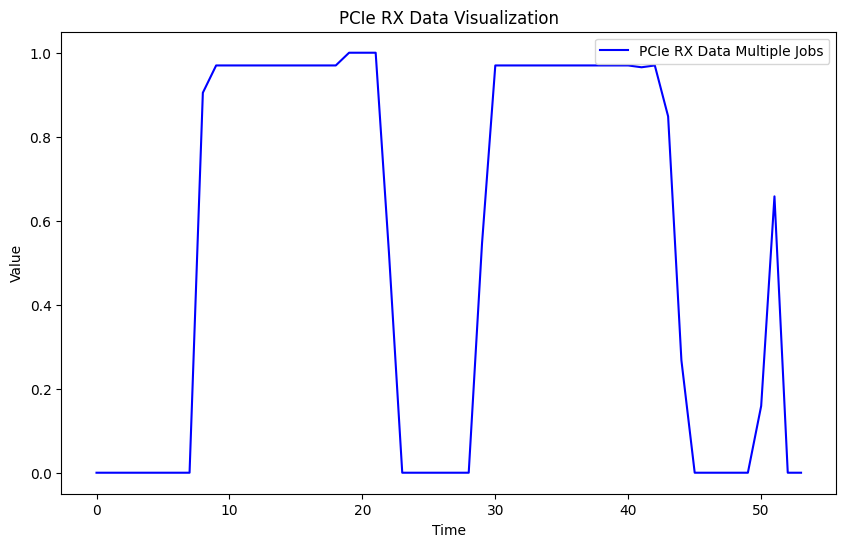

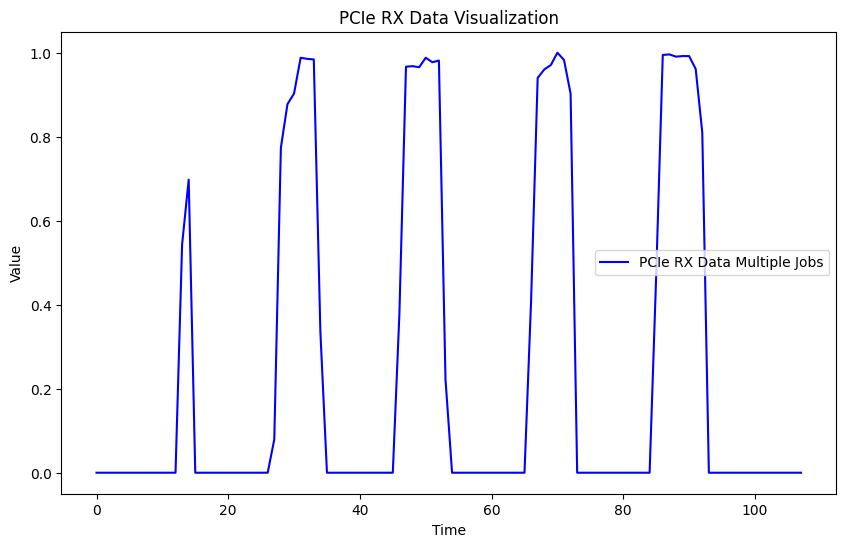

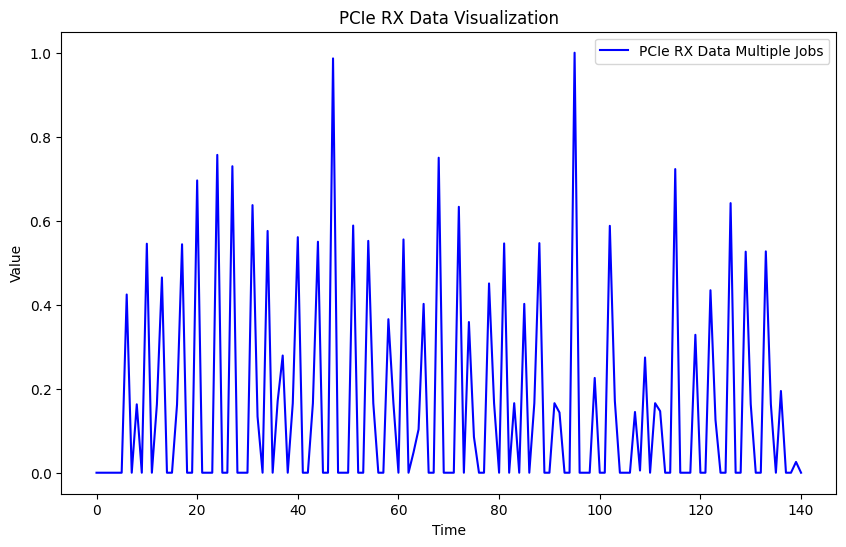

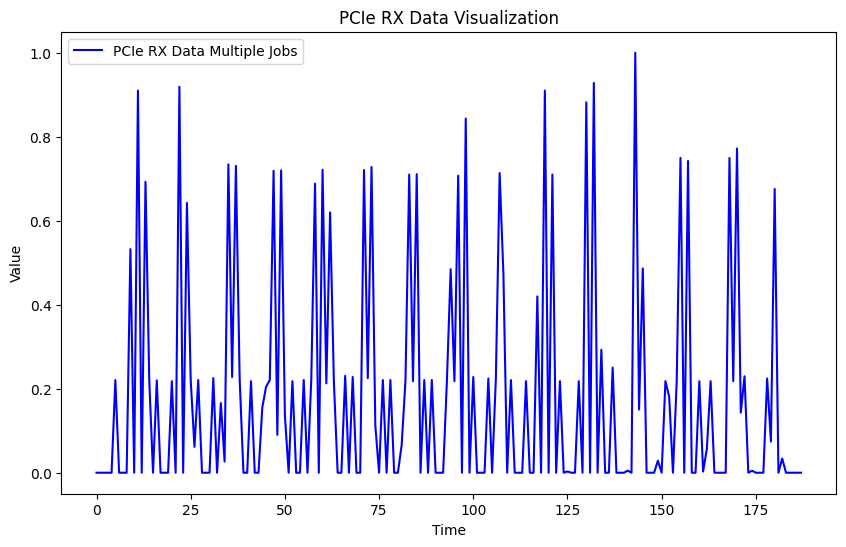

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset

target = 'SM Active'
for p in [1, 2, 3, 4]:
    df = pd.read_csv(f"./data/mig_1g.6gb_parallelism_{p}.csv")
    df.rename(columns={target: 'Value'}, inplace=True)


    data = to_time_series_dataset(df['Value'].to_numpy())
    data = TimeSeriesScalerMinMax().fit_transform(data.reshape(1,-1))

    plt.figure(figsize=(10, 6))
    plt.plot(data.reshape(-1,1), label='PCIe RX Data Multiple Jobs', color='blue')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('PCIe RX Data Visualization')
    plt.legend()
    plt.show()
